In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/home/mtech2/Desktop/Machine Learning/Assignment-1/Datasets/Loan_amount_prediction.csv")   # Change filename if needed

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print(df.shape)

print(df.info())

print(df.describe(include="all"))

(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
         Loan_ID Gender Married Dependents Education Self_Employed  \
count        614    601    

In [4]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [5]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
numerical_columns = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [7]:
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [8]:
df = df.drop("Loan_ID", axis=1)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# Drop columns not used as input
X = df.drop(["LoanAmount", "Loan_Status"], axis=1)

# Target
y = df["LoanAmount"]

In [35]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
import numpy as np


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)

X_test_std = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_std, y_train)


LinearRegression()

In [39]:
y_pred = lr.predict(X_test_std)

In [40]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)

ridge.fit(X_train_std, y_train)

ridge_pred = ridge.predict(X_test_std)

In [41]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_std, y_train)

lasso_pred = lasso.predict(X_test_std)

In [42]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

elastic.fit(X_train_std, y_train)

elastic_pred = elastic.predict(X_test_std)

In [43]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

def evaluate(y_test, pred):

    mae = mean_absolute_error(y_test,pred)

    mse = mean_squared_error(y_test,pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test,pred)

    print("MAE :",mae)
    print("MSE :",mse)
    print("RMSE:",rmse)
    print("R2  :",r2)

In [44]:

print("Linear Regression")
evaluate(y_test, lr_pred)

Linear Regression
MAE : 0.28861766809600103
MSE : 0.167604510073487
RMSE: 0.4093952980598177
R2  : 0.2873779664398304


In [45]:
print("Ridge Regression")
evaluate(y_test, ridge_pred)

Ridge Regression
MAE : 0.2886563747392081
MSE : 0.16762465432568305
RMSE: 0.4094198997675651
R2  : 0.2872923169668049


In [46]:
print("Lasso Regression")
evaluate(y_test, lasso_pred)

Lasso Regression
MAE : 0.3149859336734272
MSE : 0.2008098094407847
RMSE: 0.4481180753337056
R2  : 0.14619544128151096


In [47]:
print("Elastic Net")
evaluate(y_test, elastic_pred)

Elastic Net
MAE : 0.302188776912333
MSE : 0.18568231739091165
RMSE: 0.4309087112033263
R2  : 0.2105146182685692


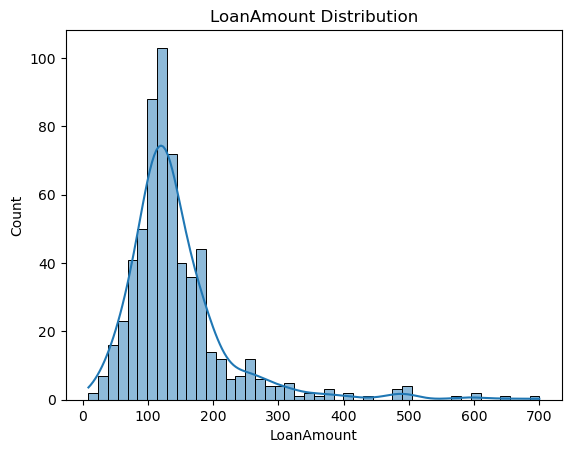

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["LoanAmount"], kde=True)
plt.title("LoanAmount Distribution")
plt.show()

In [48]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import time

ridge = Ridge()

ridge_param = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

start = time.time()

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_param,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_std, y_train)

ridge_time = time.time() - start

print("Best Parameters :", ridge_grid.best_params_)
print("Best CV R2      :", ridge_grid.best_score_)
print("Training Time   :", ridge_time)

Best Parameters : {'alpha': 100}
Best CV R2      : 0.2441271516470401
Training Time   : 1.04771089553833


In [49]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

lasso_param = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

start = time.time()

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_param,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train_std, y_train)

lasso_time = time.time() - start

print("Best Parameters :", lasso_grid.best_params_)
print("Best CV R2      :", lasso_grid.best_score_)
print("Training Time   :", lasso_time)

Best Parameters : {'alpha': 0.01}
Best CV R2      : 0.22811972977241668
Training Time   : 0.024286746978759766


In [50]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(max_iter=10000)

elastic_param = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}

start = time.time()

elastic_grid = GridSearchCV(
    estimator=elastic,
    param_grid=elastic_param,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_train_std, y_train)

elastic_time = time.time() - start

print("Best Parameters :", elastic_grid.best_params_)
print("Best CV R2      :", elastic_grid.best_score_)
print("Training Time   :", elastic_time)

Best Parameters : {'alpha': 0.1, 'l1_ratio': 0.2}
Best CV R2      : 0.2336409909276833
Training Time   : 0.03665924072265625


In [51]:
ridge_best = ridge_grid.best_estimator_
lasso_best = lasso_grid.best_estimator_
elastic_best = elastic_grid.best_estimator_

ridge_pred = ridge_best.predict(X_test_std)
lasso_pred = lasso_best.predict(X_test_std)
elastic_pred = elastic_best.predict(X_test_std)

In [52]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("=" * 50)
    print(name)
    print("=" * 50)

    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("R2   :", r2)

In [59]:
evaluate_model("Ridge Regression", y_test, lr_pred)

Ridge Regression
MAE  : 0.28861766809600103
MSE  : 0.167604510073487
RMSE : 0.4093952980598177
R2   : 0.2873779664398304


In [54]:
evaluate_model("Ridge Regression", y_test, ridge_pred)

Ridge Regression
MAE  : 0.29225473263058804
MSE  : 0.1709430527546597
RMSE : 0.4134526003723519
R2   : 0.273183127210614


In [56]:
evaluate_model("Lasso Regression", y_test, lasso_pred)

Lasso Regression
MAE  : 0.290256243123238
MSE  : 0.16909831181259719
RMSE : 0.41121565122523873
R2   : 0.2810266097096703


In [57]:
evaluate_model("Elastic Net Regression", y_test, elastic_pred)

Elastic Net Regression
MAE  : 0.2940114203183646
MSE  : 0.17429030702375684
RMSE : 0.41748090617866207
R2   : 0.25895124799065095


In [60]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred),
        mean_squared_error(y_test, elastic_pred)
    ]
})

results["RMSE"] = np.sqrt(results["MSE"])

results["R2"] = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, ridge_pred),
    r2_score(y_test, lasso_pred),
    r2_score(y_test, elastic_pred)
]

print(results)

               Model       MAE       MSE      RMSE        R2
0  Linear Regression  0.288618  0.167605  0.409395  0.287378
1   Ridge Regression  0.292255  0.170943  0.413453  0.273183
2   Lasso Regression  0.290256  0.169098  0.411216  0.281027
3        Elastic Net  0.294011  0.174290  0.417481  0.258951
